In [1]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PowerTransformer,FunctionTransformer,OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score,confusion_matrix,precision_recall_curve,average_precision_score
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTENC
from scipy.stats import uniform,loguniform,randint
import mlflow

In [2]:
df = pd.read_csv('../data/raw/ai4i2020.csv').iloc[:,2:9]

In [3]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


## Stratified Sampling

In [50]:
X = df.drop('Machine failure',axis = 1)
y = df['Machine failure']
X_main,X_test,y_main,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
X_train,X_val,y_train,y_val = train_test_split(X_main,y_main,test_size=0.2,stratify=y_main,random_state=42)

## Over Sampling with Smote

In [51]:
smote = SMOTENC(random_state=42,categorical_features=['Type'])
X_train_sampled ,y_train_sampled = smote.fit_resample(X_train,y_train)

## Scaling and Transformations

In [52]:
num_types = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Temperature Difference'
]

def func(X):
    x = X.copy()
    x["Temperature Difference"] = (
        x["Process temperature [K]"]
        - x["Air temperature [K]"]
    )
    return x
    
preprocessor = ColumnTransformer(
    transformers=[
        ('cat',OrdinalEncoder(categories=[['L','M','H']],dtype=int),['Type']),
        ('num',PowerTransformer(),num_types)
    ],remainder='passthrough'
)

In [53]:
pipe = Pipeline(
   steps= [
        ('feature_engg',FunctionTransformer(func)),
        ('preprocessor',preprocessor)
    ]
)

In [54]:
X_train_sampled['Type']

0        L
1        M
2        L
3        L
4        L
        ..
12361    L
12362    L
12363    L
12364    L
12365    L
Name: Type, Length: 12366, dtype: object

In [59]:
X_train_trans = pipe.fit_transform(X_train_sampled)
X_test_trans = pipe.transform(X_test)
X_val_trans = pipe.transform(X_val)

In [56]:
feature_names =preprocessor.get_feature_names_out()

## Experiment tracking with MLFlow

In [37]:
mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment("Predictive_Maintainace")
with mlflow.start_run(run_name='LogisticRegression'):
    param_dist ={
        "solver":['saga'],
        'l1_ratio':uniform(0.2,0.8),
        'C':uniform(0.2,4.8),
        'penalty':['elasticnet']
    }
    model = LogisticRegression()
    modelCV = RandomizedSearchCV(model,n_iter=30,param_distributions=param_dist,cv=5,random_state=42,scoring='recall',error_score='raise')
    modelCV.fit(X_train_trans,y_train_sampled)
    y_pred = modelCV.predict(X_test_trans)
    conf = confusion_matrix(y_test,y_pred)
    metrics = {'accuracy':accuracy_score(y_test,y_pred),
               'precision':precision_score(y_test,y_pred),
               'recall':recall_score(y_test,y_pred),
               'f1':f1_score(y_test,y_pred)}
    signature = mlflow.models.infer_signature(X_train_trans[:10],modelCV.predict(X_train_trans[:10]))
    model_info = mlflow.sklearn.log_model(
        sk_model=modelCV,
        name='LR_model',
        input_example=X_train_trans[:10],
        signature=signature,
        tags={
            "model_type": "LogisticRegression",
            "tuning_method": "RandomizedSearchCV",
            "stage": "experiment"}
    )
    mlflow.log_metrics(metrics)
    mlflow.log_model_params(model_id=model_info.model_id,params=modelCV.best_params_)
    mlflow.log_params(params=modelCV.best_params_)
    mlflow.log_text(str(conf),'confusion.txt')

2026/08/17 08:58:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LogisticRegression at: http://localhost:5000/#/experiments/1/runs/34121ba55f664517807d1195a91d90f9
🧪 View experiment at: http://localhost:5000/#/experiments/1


#### **Conclusion** : After multiple experiment runs it can be noticed that, **XGBoost** gives balanced scores and **RandomForest** has the highest **recall** score.

## Registering the models in model registry

In [12]:
mlflow.set_tracking_uri('http://localhost:5000')
rf_model_uri = f'models:/m-5ebb50f0447e4dc29d2371798567b226'
xgb_model_uri = f'models:/m-269eb9eeeaab4d44b965030e6231b5ec'
registerd_rf = mlflow.register_model(
    model_uri=rf_model_uri,
    name='RandomForest',
    tags={'metric':'recall','status':'success'},
    await_registration_for=300
)

registerd_xgb = mlflow.register_model(
    model_uri=xgb_model_uri,
    name='XGBoost',
    tags={'metric':'accuracy','status':'success'},
    await_registration_for=300
)

Registered model 'RandomForest' already exists. Creating a new version of this model...
2026/08/18 07:45:33 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: RandomForest, version 2
Created version '2' of model 'RandomForest'.
Registered model 'XGBoost' already exists. Creating a new version of this model...
2026/08/18 07:45:33 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XGBoost, version 2
Created version '2' of model 'XGBoost'.


## Threshold Tuning

In [57]:
mlflow.set_tracking_uri('http://localhost:5000')
# Loading the registered models
rf = 'RandomForest'
xgb = 'XGBoost'
version = 'latest'
rf_uri = f'models:/{rf}/{version}'
xgb_uri = f'models:/{xgb}/{version}'

rf_model= mlflow.sklearn.load_model(model_uri=rf_uri)
xgb_model= mlflow.sklearn.load_model(model_uri=xgb_uri)

In [78]:
rf_preds = rf_model.predict_proba(X_val_trans)[:,1]
xgb_preds = xgb_model.predict_proba(X_val_trans)[:,1]

p_rf, r_rf, thresholds_rf = precision_recall_curve(y_val, rf_preds)
auc_rf = average_precision_score(y_val,rf_preds)

p_xgb, r_xgb, thresholds_xgb = precision_recall_curve(y_val, xgb_preds)
auc_xgb = average_precision_score(y_val,xgb_preds)


#### **PR-AUC**

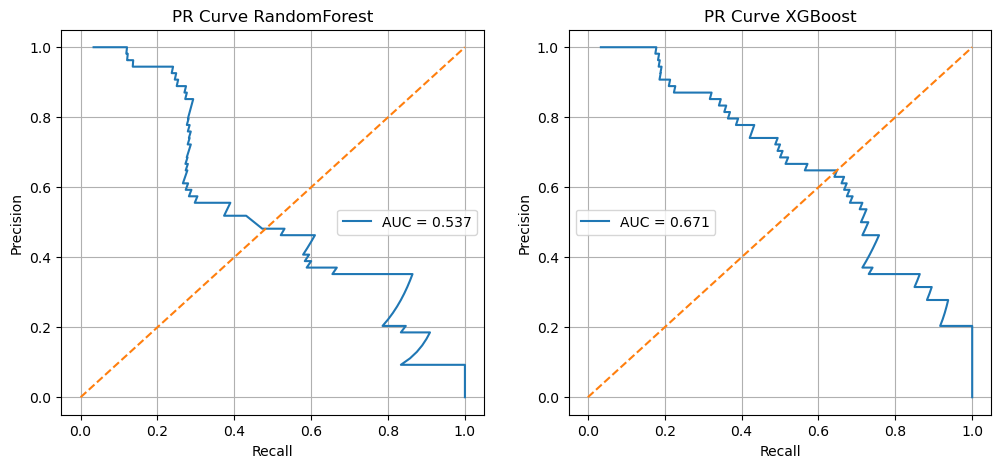

In [79]:
import matplotlib.pyplot as plt

fig,axs = plt.subplots(1,2,figsize=(12, 5))
axs[0].plot(p_rf, r_rf, label=f"AUC = {auc_rf:.3f}")
axs[0].plot([0, 1], [0, 1], linestyle="--")

axs[0].set_xlabel("Recall")
axs[0].set_ylabel("Precision")
axs[0].set_title("PR Curve RandomForest")
axs[0].grid(True)
axs[0].legend()

axs[1].plot(p_xgb, r_xgb, label=f"AUC = {auc_xgb:.3f}")
axs[1].plot([0, 1], [0, 1], linestyle="--")
axs[1].set_xlabel("Recall")
axs[1].set_ylabel("Precision")
axs[1].set_title("PR Curve XGBoost")
axs[1].legend()
axs[1].grid(True)
plt.show()

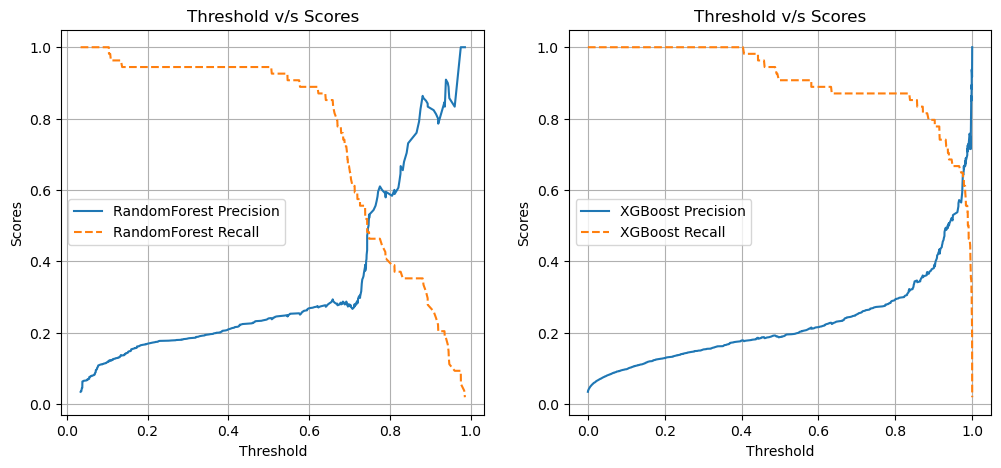

In [66]:
fig,axs = plt.subplots(1,2,figsize=(12, 5))
axs[0].plot(thresholds_rf,p_rf[:-1], label=f"RandomForest Precision")
axs[0].plot(thresholds_rf,r_rf[:-1] ,label=f"RandomForest Recall", linestyle="--")

axs[0].set_xlabel("Threshold")
axs[0].set_ylabel("Scores")
axs[0].set_title("Threshold v/s Scores")
axs[0].grid(True)
axs[0].legend()

axs[1].plot(thresholds_xgb,p_xgb[:-1] , label=f"XGBoost Precision")
axs[1].plot(thresholds_xgb,r_xgb[:-1] ,label=f"XGBoost Recall", linestyle="--")
axs[1].set_xlabel("Threshold")
axs[1].set_ylabel("Scores")
axs[1].set_title("Threshold v/s Scores")
axs[1].legend()
axs[1].grid(True)
plt.show()

### Evaluations with calculated thresholds

In [93]:
rf_best_preds = (rf_model.predict_proba(X_val_trans)[:,1]>=0.55).astype(int)
xgb_best_preds = (xgb_model.predict_proba(X_val_trans)[:,1]>=0.92).astype(int)

xgb_precision= precision_score(y_val,xgb_best_preds)
xgb_recall= recall_score(y_val,xgb_best_preds)

rf_precision= precision_score(y_val,rf_best_preds)
rf_recall= recall_score(y_val,rf_best_preds)

print("XGBoost Precision:",xgb_precision)
print("XGBoost Recall:",xgb_recall)
print("RandomForest Precision:",rf_precision)
print("RandomForest Recall:",rf_recall)

XGBoost Precision: 0.43956043956043955
XGBoost Recall: 0.7407407407407407
RandomForest Precision: 0.25
RandomForest Recall: 0.9074074074074074


#### Verdict : After hyperparam tuning and Threshold tuning the RandomForest Classifier gives the best recall and XGBoost gives the balanced scores

### Soft Voting

In [75]:
rf_probs =(rf_model.predict_proba(X_test_trans)[:,1]*0.65)
xgb_probs = (xgb_model.predict_proba(X_test_trans)[:,1]*0.81)
probs = ((rf_probs*0.2)+(xgb_probs*0.8))

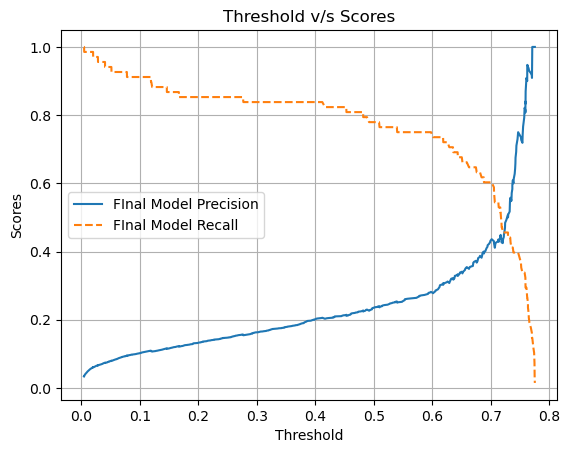

In [76]:
p_final,r_final,thr_final = precision_recall_curve(y_test,probs)

plt.plot(thr_final,p_final[:-1] , label=f"FInal Model Precision")
plt.plot(thr_final,r_final[:-1] ,label=f"FInal Model Recall", linestyle="--")

plt.xlabel("Threshold")
plt.ylabel("Scores")
plt.title("Threshold v/s Scores")
plt.grid(True)
plt.legend()
plt.show()

In [77]:
optimal_soft_threshold = 0.5
rf_final_probs = rf_model.predict_proba(X_test_trans)[:,1]
xgb_final_probs = xgb_model.predict_proba(X_test_trans)[:,1]
final_prbs = probs = ((rf_final_probs*0.55)+(xgb_final_probs*0.45))
final_preds = (final_prbs>=optimal_soft_threshold).astype(int)

f_precision = precision_score(y_test,final_preds)
f_recall = recall_score(y_test,final_preds)
print(f_precision,f_recall)

0.2222222222222222 0.7941176470588235
